# Assignment 10

## Submit your .ipynb file to Gradescope by Thursday, December 4th **by 10pm**

##### Import necessary libraries:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

<font size = "5">

1. Converting long to wide format

<font size = "3">

- Load in the data from "daily.csv". This contains the stock prices for Microsoft and Coca-Cola from 1997-2012.

- We are only interested in 3 columns: "symbol", "date", and "adjusted". Create a new DataFrame which contains only these 3 columns.

- Convert the date column to datetime format. I.e. replace the initial "date" column containing strings with one with datetime64 dtype.

- There are two unique values in the "symbol" column, which are the ticker/stock symbols for each company. They correspond to MSFT = Microsoft, and KO = Coca-Cola.

- Using ``pd.pivot`` create a new DataFrame by converting to wide format. Then reset the index, so that "date" is a proper column. Then display/print the DataFrame. The final DataFrame should look something like this:

|  | date | KO | MSFT |
| --- | --- | --- | --- |
| 0 | 1997-01-02 | 12.27 | 6.23 |
| 1 | 1997-01-03 | 12.56 | 6.46 |
| 2 | 1997-01-06 | 12.44 | 6.44 |
| ⋮ | ⋮ | ⋮ | ⋮ |

In [7]:
# your code here
df = pd.read_csv("/Users/milkywayeric2021/Documents/GitHub/qtm151fall2025/Assignments/assignment_10/data/daily.csv")

df_subset = df[["symbol", "date", "adjusted"]].copy()

df_subset["date"] = pd.to_datetime(df_subset["date"])

df_wide = df_subset.pivot(index="date", columns="symbol", values="adjusted")

df_wide = df_wide.reset_index()

print(df_wide.head())


symbol       date         KO      MSFT
0      1997-01-02  12.272199  6.232640
1      1997-01-03  12.567904  6.461713
2      1997-01-06  12.449619  6.442623
3      1997-01-07  12.863628  6.490343
4      1997-01-08  12.627052  6.366264


<font size = "5">

2. Grouping by time

<font size = "3">

- Continue using the DataFrame in wide format you created in Problem 1.

- Use ``pd.Grouper`` to create a ``TimeGrouper`` object, which will allow you to group the "date" column by **weeks**

- Group the date column by weeks and aggregate the weekly average values for both Coca-Cola and Microsoft.

- On a single figure, plot date vs. adjusted price for both companies. Label the axes and add a figure to the plot. In addition, your plot should contain a legend with two items: "Coca-Cola" and "Microsoft". The legend should have these names exactly as written. The order in which they appear doesn't matter, as long as they correspond to the correct line.


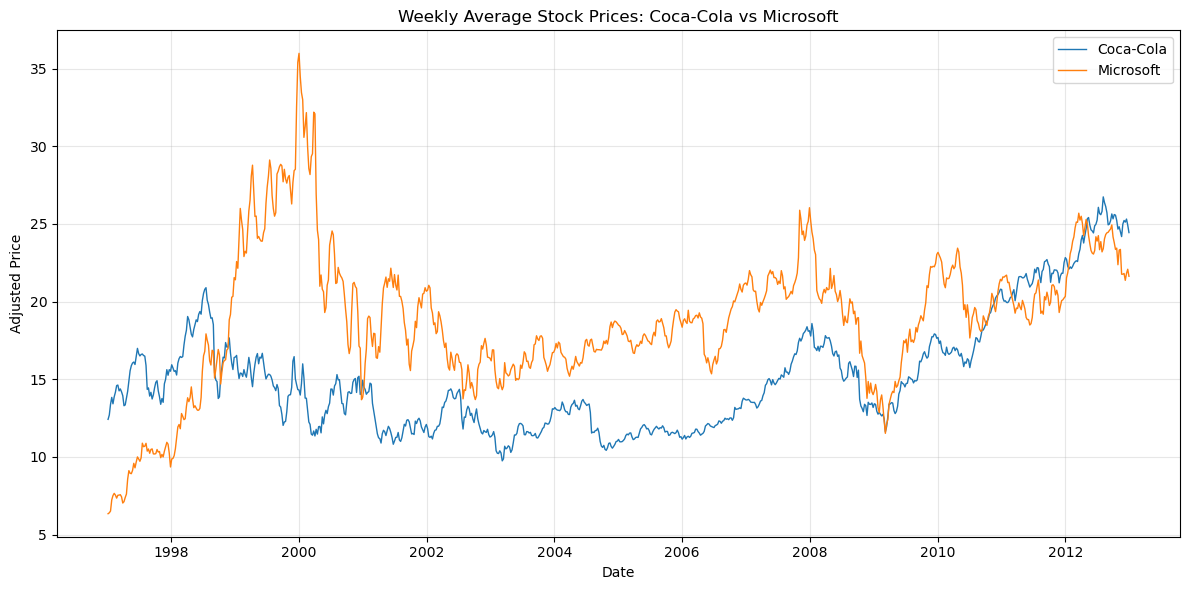

In [20]:
# your answer here
weekly_avg = df_wide.groupby(pd.Grouper(key='date', freq='W')).mean().reset_index()

plt.figure(figsize=(12, 6))

plt.plot(weekly_avg['date'], weekly_avg['KO'], label='Coca-Cola', linewidth=1)

plt.plot(weekly_avg['date'], weekly_avg['MSFT'], label='Microsoft', linewidth=1)

plt.xlabel('Date')
plt.ylabel('Adjusted Price')
plt.title('Weekly Average Stock Prices: Coca-Cola vs Microsoft')

plt.legend()

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


<font size = "5">

3. Converting wide to long format

<font size = "3">

- Use ``pd.melt`` to convert the DataFrame you created in Problem 1 back to long format.

- The variable name column should be "ticker_symbol", while the value name column should be "adjusted_price".

- Use ``.set_index`` to make "date" the index column.

- Display/print the DataFrame. The final DataFrame should look something like this:

| date | ticker_symbol | adjusted_price |
| --- | --- | --- |
| 1997-01-02 | KO/MSFT | (price value) |
| 1997-01-03 | KO/MSFT | (price value) |
| 1997-01-06 | KO/MSFT | (price value) |
| ⋮ | ⋮ | ⋮ |

- (The exact ordering of ticker_symbol and the first 3 price values can vary, depending on the exact ordering of arguments you use in ``pd.melt``)

In [21]:
# your code here
df_long = pd.melt(
    df_wide,
    id_vars=['date'],
    value_vars=['KO', 'MSFT'],
    var_name='ticker_symbol',
    value_name='adjusted_price'
)

df_long = df_long.set_index('date')
print(df_long.head())


           ticker_symbol  adjusted_price
date                                    
1997-01-02            KO       12.272199
1997-01-03            KO       12.567904
1997-01-06            KO       12.449619
1997-01-07            KO       12.863628
1997-01-08            KO       12.627052


<font size = "5">

4. Search for strings 

<font size = "3">

- Load in the from "Datafiniti_Hotel_Reviews.csv" and save it to a DataFrame named ``hotels``

- The "name" column contains the name of each hotel for which a customer review is available. The names are very specific, for example there is "Hampton Inn and Suites Napa" as well as "Hampton Inn Atlanta-Perimeter Center".

- Using ``.str.contains``, create a Boolean Pandas Series where each entry is "True" if the "name" of the hotel contains the string "Hampton Inn".

- Using this Boolean Series, create a new DataFrame called ``hampton`` which contains all rows from the original DataFrame which have the string "Hampton Inn" in the hotel name.

In [26]:
# your code here
hotels = pd.read_csv("/Users/milkywayeric2021/Documents/GitHub/qtm151fall2025/Assignments/assignment_10/data/Datafiniti_Hotel_Reviews.csv")

hampton_mask = hotels['name'].str.contains('Hampton Inn')

hampton = hotels[hampton_mask]

print(f"Original dataset: {hotels.shape}")
print(f"Hampton Inn hotels: {hampton.shape}")
print(hampton[['name']].head())


Original dataset: (10000, 25)
Hampton Inn hotels: (689, 25)
                                    name
9   Hampton Inn Suites PortlandVancouver
10  Hampton Inn Suites PortlandVancouver
11  Hampton Inn Suites PortlandVancouver
12  Hampton Inn Suites PortlandVancouver
13  Hampton Inn Suites PortlandVancouver


<font size = "5">

5. Searching with wild cards 

<font size = "3">

Use the DataFrame ``hampton`` you created in Problem 4.

The text reviews can be found in the "reviews.text" column of the DataFrame. Use ``str.findall`` to return a Pandas Series with all occurences of strings containing all consecutive characters of any kind immediately followed by the string "nice hotel". 

To make this more clear, consider the following string:

- "This was a really nice hotel. Very nice. Love this hotel"

Then the return value of ``str.findall`` should have the sub-string "This was a really nice hotel" as its corresponding element.

Using the ``str.len`` method, create a new Series where all the empty "non-matches" are omitted, leaving only the phrases that matched the search term above.

Repeat this process for the phrase "Nice hotel" with a capital "N". (Again, it should include all consecutive characters before this phrase). 

Finally, repeat the process one more time, but in such a way that **both** "nice hotel" and "Nice hotel" are included in the match (again with all consecutive characters preceding them included).

To be clear, your code should create a total of **six** Pandas series, 3 that include empty "non-matches" and 3 where these are excluded.

In [29]:
# your code here
nice_hotel_matches = hampton['reviews.text'].str.findall(r'.*nice hotel')
nice_hotel_non_empty = nice_hotel_matches[nice_hotel_matches.str.len() > 0]
Nice_hotel_matches = hampton['reviews.text'].str.findall(r'.*Nice hotel')
Nice_hotel_non_empty = Nice_hotel_matches[Nice_hotel_matches.str.len() > 0]
both_matches = hampton['reviews.text'].str.findall(r'.*[Nn]ice hotel')
both_non_empty = both_matches[both_matches.str.len() > 0]
